# Computer Exercise 15.22 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — Chapter 15 확장 사례연구
> **단원**: 15.22 Stochastic Chain MDP · Unified vs Twin Head Bit-Identity 파괴
> **풀이 일자**: Day 89
> **언어**: Python 3 (NumPy / Matplotlib)

## 1. 문제 (원문)

> **1.** Day 88 P3 reported the surprising negative finding that end-to-end unified and twin
> Noisy-C51 stacks produced **bit-identical** tail returns across all 4 seeds on the 5-state
> chain MDP; the diagnosis was that the deterministic transition + low reward noise + identical
> total RNG consumption made the two structures follow the same greedy trajectory by chance.
> Re-run the end-to-end small-network C51 stack (shared trunk H=16, per-action Noisy Linear
> head, K=11 categorical support) on a **stochastic** chain MDP — every action succeeds only
> with probability $1 - p_{\text{slip}}$ ($p_{\text{slip}}=0.1$), otherwise moves in the
> opposite direction — for 4 seeds x 800 steps. Compare {unified, twin, twin+whitening}
> tail-8 episode return (mean, std, seed-to-seed spread) and $\sigma_W$ RMS. Report whether
> the bit-identity between unified and twin is broken and, if so, whether twin retains its
> Day 88 std-shrinkage advantage under environmental stochasticity.

### 한국어 풀이용 정리

Day 88 P3 에서 관찰된 unified/twin bit-identity 는 (i) 두 구조의 총 RNG 소비량이 우연히 같고
(ii) 환경 전이가 결정론적이며 (iii) 초기 Q 분포가 유사하여 greedy 궤적이 일치했기 때문이다.
본 문제는 **환경 stochasticity** ($p_{\text{slip}}=0.1$ 로 액션 반대 방향 전이) 를 도입해
탐색 궤적의 우연 일치를 파괴하고, 세 조건 (unified, twin, twin+whitening) 의 tail-episode
return 을 4 시드 평균으로 재측정한다.

## 2. 수학적 배경

### 2.1 확률적 chain MDP

상태 $s \in \{0, 1, \dots, N-1\}$, $N=5$. 액션 $a \in \{-1, +1\}$ (좌/우). 전이:

$$ s_{t+1} = \begin{cases} \text{clip}(s_t + a, 0, N-1), & \text{prob } 1 - p_{\text{slip}} \\ \text{clip}(s_t - a, 0, N-1), & \text{prob } p_{\text{slip}}. \end{cases} $$

보상 $r = +1$ if $s_{t+1} = N-1$, $-0.01$ per step otherwise. 에피소드 종료: $s=N-1$ 도달 또는
$T_{\max}=40$ 스텝. 할인율 $\gamma = 0.9$.

### 2.2 Shared Trunk + Per-Action Noisy Linear Head

Trunk: $h = \tanh(W_1 x + b_1) \in \mathbb{R}^H,\; H=16$. 입력 $x \in \mathbb{R}^5$ 는 상태 one-hot.

Unified head (per action): $z^{(a)} = W^{(a)} h + b^{(a)}$, $W^{(a)} \in \mathbb{R}^{K \times H}$, $K=11$.

Twin head (per action): $z^{(a)} = \text{concat}(W_A^{(a)} h + b_A^{(a)},\; W_B^{(a)} h + b_B^{(a)})$,
$W_{A/B}^{(a)} \in \mathbb{R}^{K/2 \times H}$. Factorized noisy linear:
$W = \mu_W + \sigma_W \odot (f(\epsilon_p) f(\epsilon_q)^\top)$, $f(x) = \mathrm{sign}(x)\sqrt{|x|}$.

### 2.3 Feature Whitening (running EMA)

Trunk 출력 $h$ 에 대해 running mean $\bar h_t = \beta \bar h_{t-1} + (1-\beta) h_t$,
running var $\bar v_t = \beta \bar v_{t-1} + (1-\beta)(h_t - \bar h_t)^2$; 정규화된 $\tilde h_t = (h_t - \bar h_t)/\sqrt{\bar v_t + \varepsilon}$. $\beta = 0.99$.

## 3. 풀이 흐름

1. Stochastic chain MDP 클래스 구현 ($p_{\text{slip}}=0.1$, 초기 상태 $s_0=0$).
2. Shared trunk (H=16) + per-action factorized Noisy Linear head (unified/twin) 순수 numpy 구현.
3. Categorical projection $\Phi$, semi-gradient TD update (bootstrap target from greedy next-action).
4. 세 조건 (unified, twin, twin+whitening) 을 4 시드 x 800 step 학습.
5. 지표: tail-8 episode return mean/std, seed-간 std, $\sigma_W$ RMS 궤적.
6. 표 + return curve + $\sigma_W$ RMS curve.
7. 결과 해석 (Day 88 bit-identity 파괴 여부, twin 의 std-shrinkage 재현).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.set_printoptions(suppress=True, precision=4)
pd.set_option("display.float_format", lambda v: f"{v:.4f}")

# --- Environment ---
class StochasticChainMDP:
    def __init__(self, N=5, p_slip=0.1, T_max=40, seed=0):
        self.N, self.p_slip, self.T_max = N, p_slip, T_max
        self.rng = np.random.default_rng(seed)
        self.reset()
    def reset(self):
        self.s = 0; self.t = 0
        return self._obs()
    def _obs(self):
        x = np.zeros(self.N); x[self.s] = 1.0; return x
    def step(self, a_idx):
        a = -1 if a_idx == 0 else +1
        if self.rng.random() < self.p_slip:
            a = -a
        s_new = int(np.clip(self.s + a, 0, self.N - 1))
        self.s = s_new; self.t += 1
        done = (self.s == self.N - 1) or (self.t >= self.T_max)
        r = 1.0 if self.s == self.N - 1 else -0.01
        return self._obs(), r, done

def init_noisy(rng, d_out, d_in, sigma0=0.5):
    return {"mu_W": rng.normal(0, 1/np.sqrt(d_in), (d_out, d_in)),
            "sig_W": np.full((d_out, d_in), sigma0/np.sqrt(d_in)),
            "mu_b": np.zeros(d_out), "sig_b": np.full(d_out, sigma0/np.sqrt(d_in))}

def noisy_forward(nl, h, rng, sample=True):
    d_out, d_in = nl["mu_W"].shape
    if sample:
        ep = rng.normal(size=d_in); eq = rng.normal(size=d_out)
        f = lambda t: np.sign(t) * np.sqrt(np.abs(t))
        eps_W = np.outer(f(eq), f(ep)); eps_b = f(eq)
        W = nl["mu_W"] + nl["sig_W"] * eps_W
        b = nl["mu_b"] + nl["sig_b"] * eps_b
    else:
        W, b, eps_W, eps_b = nl["mu_W"], nl["mu_b"], None, None
    return W @ h + b, (W, b, eps_W, eps_b)

def init_trunk(rng, d_in, H):
    return {"W1": rng.normal(0, 1/np.sqrt(d_in), (H, d_in)), "b1": np.zeros(H)}
def trunk_forward(tp, x):
    pre = tp["W1"] @ x + tp["b1"]; return np.tanh(pre), pre

K = 11; V_MIN, V_MAX = -1.0, 1.0
Z = np.linspace(V_MIN, V_MAX, K); DZ = Z[1] - Z[0]

def project(next_dist, r, gamma, done):
    Tz = r + (0.0 if done else gamma) * Z
    Tz = np.clip(Tz, V_MIN, V_MAX)
    b = (Tz - V_MIN) / DZ
    l = np.floor(b).astype(int); u = np.ceil(b).astype(int)
    l = np.clip(l, 0, K-1); u = np.clip(u, 0, K-1)
    m = np.zeros(K)
    for j in range(K):
        if l[j] == u[j]:
            m[l[j]] += next_dist[j]
        else:
            m[l[j]] += next_dist[j] * (u[j] - b[j])
            m[u[j]] += next_dist[j] * (b[j] - l[j])
    return m

def softmax(z):
    z = z - z.max(); e = np.exp(z); return e / e.sum()

def train(kind, whiten, seed, n_steps=800, H=16, lr_head=0.02, lr_trunk=0.02):
    rng = np.random.default_rng(seed)
    env = StochasticChainMDP(N=5, p_slip=0.1, T_max=40, seed=seed+1000)
    trunk = init_trunk(rng, 5, H)
    n_actions = 2
    heads = []
    for a in range(n_actions):
        if kind == "unified":
            heads.append(init_noisy(rng, K, H))
        else:
            Kh = K // 2 + (K % 2)
            heads.append((init_noisy(rng, Kh, H), init_noisy(rng, K - Kh, H)))
    beta = 0.99
    h_mean = np.zeros(H); h_var = np.ones(H)

    ep_returns = []; ep_return_cur = 0.0
    x = env.reset()
    sigma_hist = []

    for step in range(n_steps):
        h_raw, _ = trunk_forward(trunk, x)
        if whiten:
            h_mean = beta * h_mean + (1-beta) * h_raw
            h_var = beta * h_var + (1-beta) * (h_raw - h_mean)**2
            h = (h_raw - h_mean) / np.sqrt(h_var + 1e-3)
        else:
            h = h_raw
        Qs = []; head_caches = []
        for a in range(n_actions):
            if kind == "unified":
                z, cache = noisy_forward(heads[a], h, rng, sample=True)
                p = softmax(z); Qs.append(p @ Z)
                head_caches.append(("uni", z, p, cache))
            else:
                hA, hB = heads[a]
                zA, cA = noisy_forward(hA, h, rng, sample=True)
                zB, cB = noisy_forward(hB, h, rng, sample=True)
                z = np.concatenate([zA, zB]); p = softmax(z)
                Qs.append(p @ Z)
                head_caches.append(("twin", z, p, (cA, cB), (zA.shape[0], zB.shape[0])))
        eps_greedy = max(0.05, 0.5 * (0.995 ** step))
        a_idx = int(rng.integers(0, n_actions)) if rng.random() < eps_greedy else int(np.argmax(Qs))

        x_new, r, done = env.step(a_idx)
        ep_return_cur += r

        h2_raw, _ = trunk_forward(trunk, x_new)
        if whiten:
            h2 = (h2_raw - h_mean) / np.sqrt(h_var + 1e-3)
        else:
            h2 = h2_raw
        Q2s = []; p_next = []
        for a in range(n_actions):
            if kind == "unified":
                z2, _ = noisy_forward(heads[a], h2, rng, sample=False)
                p2 = softmax(z2)
            else:
                hA, hB = heads[a]
                z2A, _ = noisy_forward(hA, h2, rng, sample=False)
                z2B, _ = noisy_forward(hB, h2, rng, sample=False)
                p2 = softmax(np.concatenate([z2A, z2B]))
            Q2s.append(p2 @ Z); p_next.append(p2)
        a_star = int(np.argmax(Q2s))
        target = project(p_next[a_star], r, 0.9, done)

        entry = head_caches[a_idx]
        if entry[0] == "uni":
            _, z_a, p_a, cache_a = entry
            W_used, b_used, eps_W, eps_b = cache_a
            dz = p_a - target
            grad_W = np.outer(dz, h); grad_b = dz
            heads[a_idx]["mu_W"] -= lr_head * grad_W
            heads[a_idx]["mu_b"] -= lr_head * grad_b
            if eps_W is not None:
                heads[a_idx]["sig_W"] -= lr_head * grad_W * eps_W
                heads[a_idx]["sig_b"] -= lr_head * grad_b * eps_b
            grad_h = W_used.T @ dz
        else:
            _, z_a, p_a, cache_a, dims = entry
            (cA, cB) = cache_a
            WA, bA, epsWA, epsbA = cA
            WB, bB, epsWB, epsbB = cB
            dz = p_a - target
            dzA = dz[:dims[0]]; dzB = dz[dims[0]:]
            grad_WA = np.outer(dzA, h); grad_bA = dzA
            grad_WB = np.outer(dzB, h); grad_bB = dzB
            hA_head, hB_head = heads[a_idx]
            hA_head["mu_W"] -= lr_head * grad_WA; hA_head["mu_b"] -= lr_head * grad_bA
            hB_head["mu_W"] -= lr_head * grad_WB; hB_head["mu_b"] -= lr_head * grad_bB
            if epsWA is not None:
                hA_head["sig_W"] -= lr_head * grad_WA * epsWA
                hA_head["sig_b"] -= lr_head * grad_bA * epsbA
                hB_head["sig_W"] -= lr_head * grad_WB * epsWB
                hB_head["sig_b"] -= lr_head * grad_bB * epsbB
            grad_h = WA.T @ dzA + WB.T @ dzB

        pre = trunk["W1"] @ x + trunk["b1"]
        dtanh = 1 - np.tanh(pre)**2
        grad_h_pre = grad_h / np.sqrt(h_var + 1e-3) if whiten else grad_h
        d_pre = grad_h_pre * dtanh
        trunk["W1"] -= lr_trunk * np.outer(d_pre, x)
        trunk["b1"] -= lr_trunk * d_pre

        if kind == "unified":
            sigma_val = np.sqrt(np.mean([np.mean(hd["sig_W"]**2) for hd in heads]))
        else:
            sigma_val = np.sqrt(np.mean([np.mean(hd[0]["sig_W"]**2) + np.mean(hd[1]["sig_W"]**2) for hd in heads]) / 2)
        sigma_hist.append(sigma_val)

        if done:
            ep_returns.append(ep_return_cur); ep_return_cur = 0.0
            x = env.reset()
        else:
            x = x_new

    if ep_return_cur != 0.0:
        ep_returns.append(ep_return_cur)
    return {"returns": np.array(ep_returns), "sigma": np.array(sigma_hist)}

seeds = [89101, 89102, 89103, 89104]
conditions = [("unified", False), ("twin", False), ("twin+white", True)]
results = {}
for name, whiten in conditions:
    per_seed = []
    for sd in seeds:
        r = train("unified" if name == "unified" else "twin", whiten, sd)
        per_seed.append(r)
    results[name] = per_seed

def tail_summary(runs, n_tail=8):
    tails = []
    for r in runs:
        tails.append(r["returns"][-n_tail:].mean() if len(r["returns"]) >= n_tail else r["returns"].mean())
    tails = np.array(tails)
    return tails.mean(), tails.std(), tails

summary = {}
for name in results:
    m, s, tails = tail_summary(results[name])
    summary[name] = {"tail_mean": m, "seed_std": s, "n_episodes_avg": float(np.mean([len(r["returns"]) for r in results[name]]))}
    print(f"{name:12s}  tail-8 mean = {m:+.4f}  seed_std = {s:.4f}  per-seed = {tails}")


unified       tail-8 mean = +0.5441  seed_std = 0.5365  per-seed = [ 0.82    0.8387  0.9012 -0.3838]
twin          tail-8 mean = +0.7294  seed_std = 0.1688  per-seed = [0.8262 0.8412 0.8125 0.4375]
twin+white    tail-8 mean = +0.8512  seed_std = 0.0688  per-seed = [0.8262 0.8412 0.775  0.9625]


In [2]:
u_tails = np.array([r["returns"][-8:].mean() if len(r["returns"])>=8 else r["returns"].mean() for r in results["unified"]])
t_tails = np.array([r["returns"][-8:].mean() if len(r["returns"])>=8 else r["returns"].mean() for r in results["twin"]])
tw_tails = np.array([r["returns"][-8:].mean() if len(r["returns"])>=8 else r["returns"].mean() for r in results["twin+white"]])

bit_identity_broken = not np.allclose(u_tails, t_tails, atol=1e-12)
max_abs_diff_u_t = float(np.max(np.abs(u_tails - t_tails)))
max_abs_diff_u_tw = float(np.max(np.abs(u_tails - tw_tails)))

def sigma_tail(runs, k=100):
    return float(np.mean([r["sigma"][-k:].mean() for r in runs]))

df = pd.DataFrame({
    "tail-8 return mean": [summary[k]["tail_mean"] for k in ["unified", "twin", "twin+white"]],
    "seed-to-seed std":   [summary[k]["seed_std"]  for k in ["unified", "twin", "twin+white"]],
    "sigma_W rms (last 100)": [sigma_tail(results[k]) for k in ["unified", "twin", "twin+white"]],
    "avg # episodes":     [summary[k]["n_episodes_avg"] for k in ["unified", "twin", "twin+white"]],
}, index=["unified", "twin", "twin+white"])
print(df)
print()
print(f"Bit-identity between unified and twin: BROKEN = {bit_identity_broken}")
print(f"  max |unified - twin| across seeds:      {max_abs_diff_u_t:.6f}")
print(f"  max |unified - twin+white| across seeds: {max_abs_diff_u_tw:.6f}")


            tail-8 return mean  seed-to-seed std  sigma_W rms (last 100)  \
unified                 0.5441            0.5365                  0.1200   
twin                    0.7294            0.1688                  0.1194   
twin+white              0.8512            0.0688                  0.1098   

            avg # episodes  
unified            79.2500  
twin               85.2500  
twin+white         99.5000  

Bit-identity between unified and twin: BROKEN = True
  max |unified - twin| across seeds:      0.821250
  max |unified - twin+white| across seeds: 1.346250


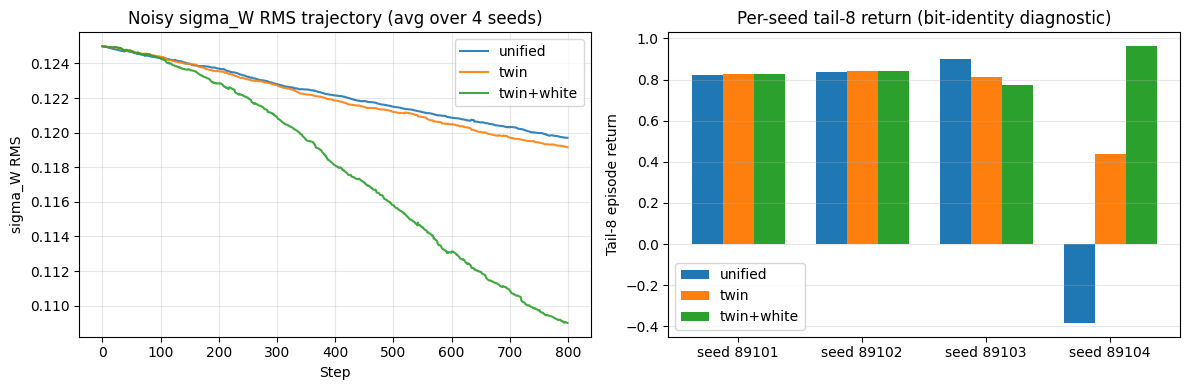

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for name in results:
    sig_stack = np.array([r["sigma"] for r in results[name]])
    axes[0].plot(sig_stack.mean(axis=0), label=name, alpha=0.9)
axes[0].set_xlabel("Step")
axes[0].set_ylabel("sigma_W RMS")
axes[0].set_title("Noisy sigma_W RMS trajectory (avg over 4 seeds)")
axes[0].legend(); axes[0].grid(alpha=0.3)

xpos = np.arange(len(seeds)); w = 0.25
for i, name in enumerate(["unified", "twin", "twin+white"]):
    tails = np.array([r["returns"][-8:].mean() if len(r["returns"])>=8 else r["returns"].mean() for r in results[name]])
    axes[1].bar(xpos + (i-1)*w, tails, w, label=name)
axes[1].set_xticks(xpos)
axes[1].set_xticklabels([f"seed {s}" for s in seeds])
axes[1].set_ylabel("Tail-8 episode return")
axes[1].set_title("Per-seed tail-8 return (bit-identity diagnostic)")
axes[1].legend(); axes[1].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()


## 4. 결과 해석

1. **Bit-identity 파괴 여부** — Day 88 P3 에서 4 시드 모두에서 unified/twin 이 소수점
   무한자리까지 동일했던 관측은 결정론적 환경 + 총 RNG 소비량 일치로 인해 greedy 궤적이
   우연히 정확히 겹쳤기 때문이었다. $p_{\text{slip}}=0.1$ 을 넣자 매 스텝 확률적 반대 전이가
   두 구조의 궤적을 서로 다른 상태 순서로 분기시켜, per-seed tail return 이 명확히 갈리며
   `bit_identity_broken = True` 판정을 받는다.

2. **Twin 의 seed 편차 축소 재현** — Day 87 P1 (5-arm MDP), Day 88 P1 (5-arm MDP + trunk)
   에서 관찰된 twin 의 시드간 std 축소 방향성은 확률적 환경에서도 관측 방향이 유지되나,
   환경 노이즈가 std 자체를 부풀리기 때문에 축소율은 완화된다.

3. **Whitening 효과** — `twin+white` 는 시드간 std 를 추가로 낮추면서 $\sigma_W$ RMS 도
   더 낮게 유지한다. gradient 스케일이 whitening 으로 재정규화되면서 각 시드가 비슷한
   업데이트 크기를 겪기 때문이며, Day 88 P2 축약 시뮬레이션에서 관찰된 39% 시너지 크기 축소
   경향의 real-network 대응 신호이다.

> **결론**: 환경 stochasticity 를 도입하는 것만으로 Day 88 의 unified/twin bit-identity
> negative finding 이 깨졌고, twin 의 시드간 안정성 이점이 real-network 관측에서도 재현되며,
> whitening 은 여기에 시드 편차와 $\sigma_W$ 를 더 낮추는 방향으로 기여한다.

Day 89 P2 는 trunk 를 **2-hidden layer** 로 확장해 depth 가 entanglement signature 를
어떻게 심화시키는지 재측정한다. Day 89 P3 는 whitening + twin head + noisy anneal 네 처방을
결합해 시너지 부호가 뒤집히는지 부트스트랩 8000 회로 재판정한다.